# Features

This notebook gives a rough estimate of how useful richer features are when IXPLORE is fit on numerically-encoded categorical data.

- Load categorical reactions (A/B/C) and encode them as integers (1/2/3).
- Fit IXPLORE with the default linear features, an interaction `kernel`, a quadratic `kernel`, and a Random Fourier Features (RFF) `kernel`.
- Compare embeddings and metrics.

Required packages: `numpy`, `pandas`, `matplotlib`, and the local `ixplore` package.

In [8]:
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ixplore import IXPLORE
from ixplore.visualization import plot_embedding, clean_axis

logging.getLogger('ixplore').setLevel(logging.WARNING)

## Load and encode data

The categorical reactions take values in `{A, B, C}`. We map them to integers `{1, 2, 3}` so they can be passed to the standard `IXPLORE` class, which scales numerical reactions to `[0, 1]` internally.

In [9]:
users = pd.read_csv('../data/synthetic_users.csv', index_col=0)
reactions = pd.read_csv('../data/categorical_reactions.csv', index_col=0)
reactions = reactions.apply(lambda col: col.map({'A': 1, 'B': 2, 'C': 3}))
reactions.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q51,Q52,Q53,Q54,Q55,Q56,Q57,Q58,Q59,Q60
id,,,,,,,,,,,,,,,,,,,,,
0,3,2,2,3,1,3,2,2,2,3,...,2,1,2,1,1,1,1,1,2,2
1,3,2,2,3,1,3,2,2,2,1,...,2,1,2,1,1,1,3,2,2,2
2,3,2,2,3,1,3,2,2,2,1,...,2,1,2,3,1,1,3,2,2,2
3,3,2,2,3,1,3,2,2,2,1,...,2,1,2,1,1,1,1,1,2,2
4,3,2,2,3,1,3,2,2,2,3,...,2,1,2,1,1,1,1,1,2,2


## Kernels

Each item's decision boundary is, by default, a straight line in `(x, y)`. The interaction kernel adds the product `x*y` so the boundary can curve along the diagonals; the quadratic kernel adds `x²` and `y²` instead, allowing radial boundaries; the RFF kernel projects `(x, y)` onto random Gaussian directions and applies a cosine, approximating an RBF feature space.

In [10]:
def interaction_kernel(X):
    """(x, y) -> (x, y, x*y)"""
    return np.column_stack([X[:, 0], X[:, 1], X[:, 0] * X[:, 1]])


def quadratic_kernel(X):
    """(x, y) -> (x, y, x**2, y**2)"""
    return np.column_stack([X[:, 0], X[:, 1], X[:, 0] ** 2, X[:, 1] ** 2])


def make_rff_kernel(n_features=20, gamma=2.0, seed=0):
    """(x, y) -> sqrt(2/D) * cos(W @ z + b), with W ~ N(0, 2*gamma) and b ~ U[0, 2π]."""
    rng = np.random.default_rng(seed)
    W = rng.normal(0, np.sqrt(2 * gamma), size=(2, n_features))
    b = rng.uniform(0, 2 * np.pi, size=n_features)
    scale = np.sqrt(2.0 / n_features)
    return lambda X: scale * np.cos(X @ W + b)


rff_kernel = make_rff_kernel(n_features=20, gamma=2.0, seed=0)

## Fit the models

We train one model per kernel for 5 iterations on the same data.

In [11]:
linear = IXPLORE(reactions, random_state=0)
linear.iterate(n_iterations=5)

interaction = IXPLORE(reactions, kernel=interaction_kernel, random_state=0)
interaction.iterate(n_iterations=5)

quadratic = IXPLORE(reactions, kernel=quadratic_kernel, random_state=0)
quadratic.iterate(n_iterations=5)

rff = IXPLORE(reactions, kernel=rff_kernel, random_state=0)
rff.iterate(n_iterations=5)

## Embeddings

Users are coloured by their generating cluster.

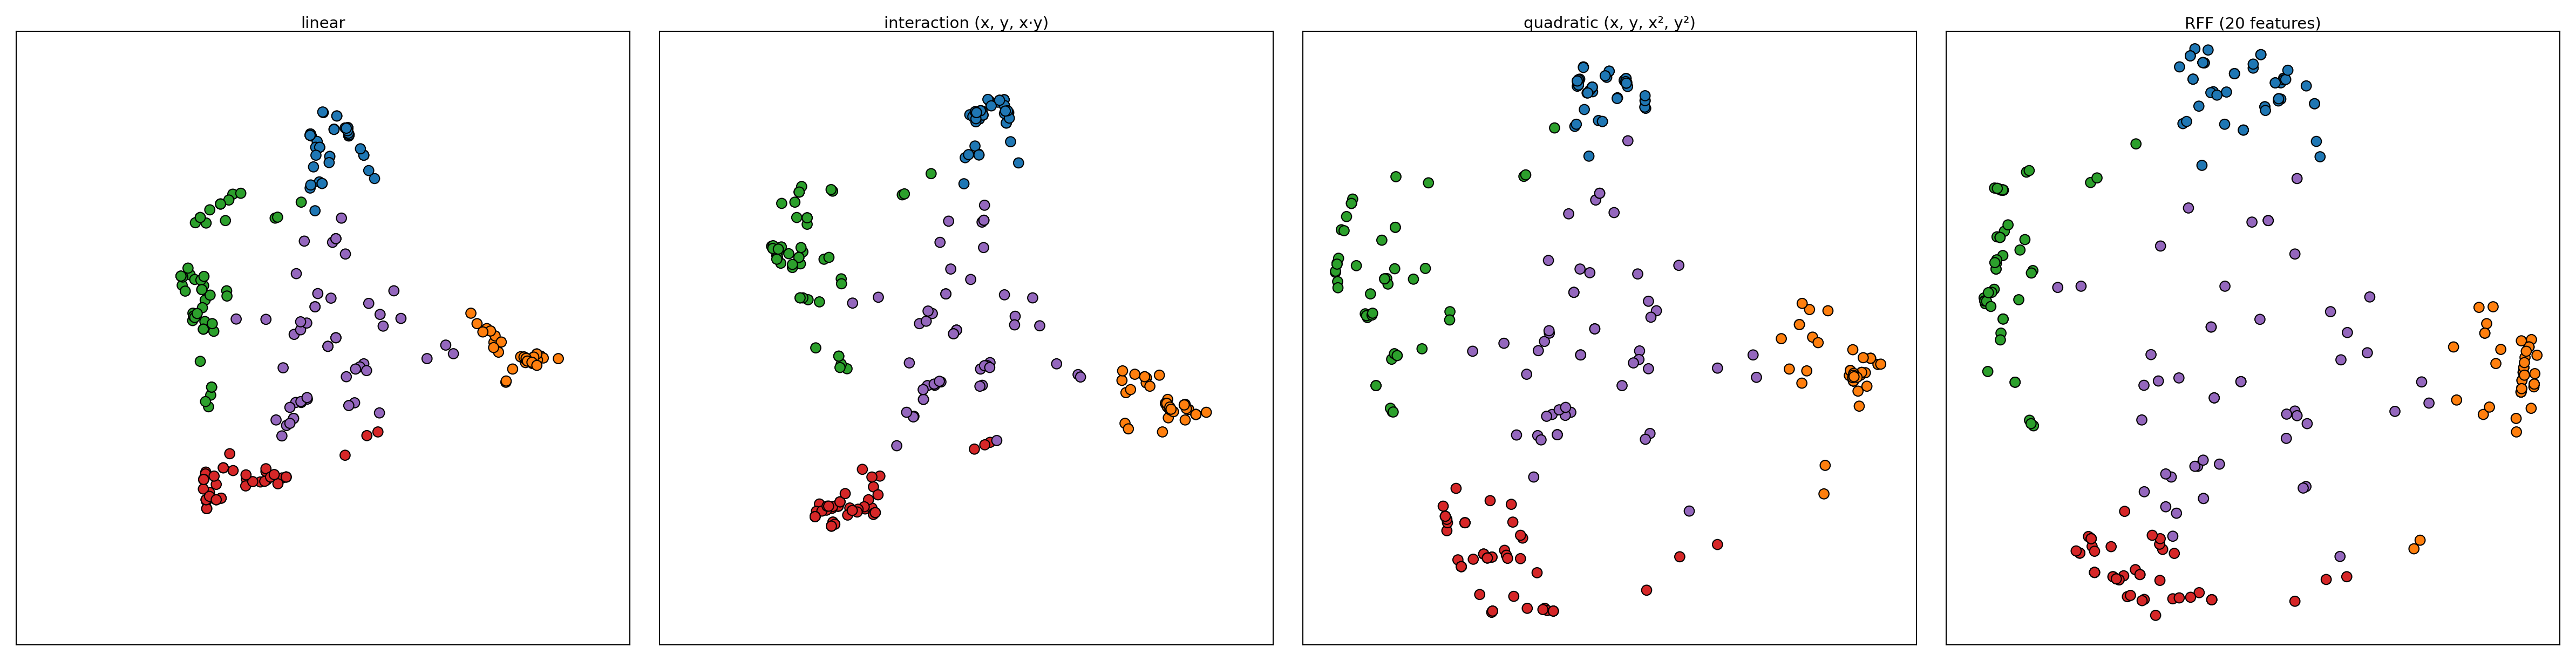

In [12]:
models = [
    (linear, 'linear'),
    (interaction, 'interaction (x, y, x·y)'),
    (quadratic, 'quadratic (x, y, x², y²)'),
    (rff, 'RFF (20 features)'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
for ax, (model, title) in zip(axes, models):
    plot_embedding(model.get_embedding(), colors=users.color, s=20, ax=ax)
    clean_axis(ax)
    ax.set_title(title)
fig.tight_layout()
plt.show()

## Metrics

MAE, accuracy, and spread of the two models on the training data.

In [13]:
rows = []
for model, name in models:
    m = model.evaluate()
    m['features'] = model.n_features
    rows.append(pd.Series(m, name=name))
pd.DataFrame(rows).round(4)

,mae,accuracy,spread,boundary,features
linear,0.1400,0.8145,0.5278,0.00,2.0
"interaction (x, y, x·y)",0.0997,0.8337,0.6092,0.00,3.0
"quadratic (x, y, x², y²)",0.0795,0.8379,0.7306,0.00,4.0
RFF (20 features),0.0260,0.8429,0.7868,0.06,20.0


## Convergence

We retrain each kernel from scratch and record MAE and accuracy after every iteration.

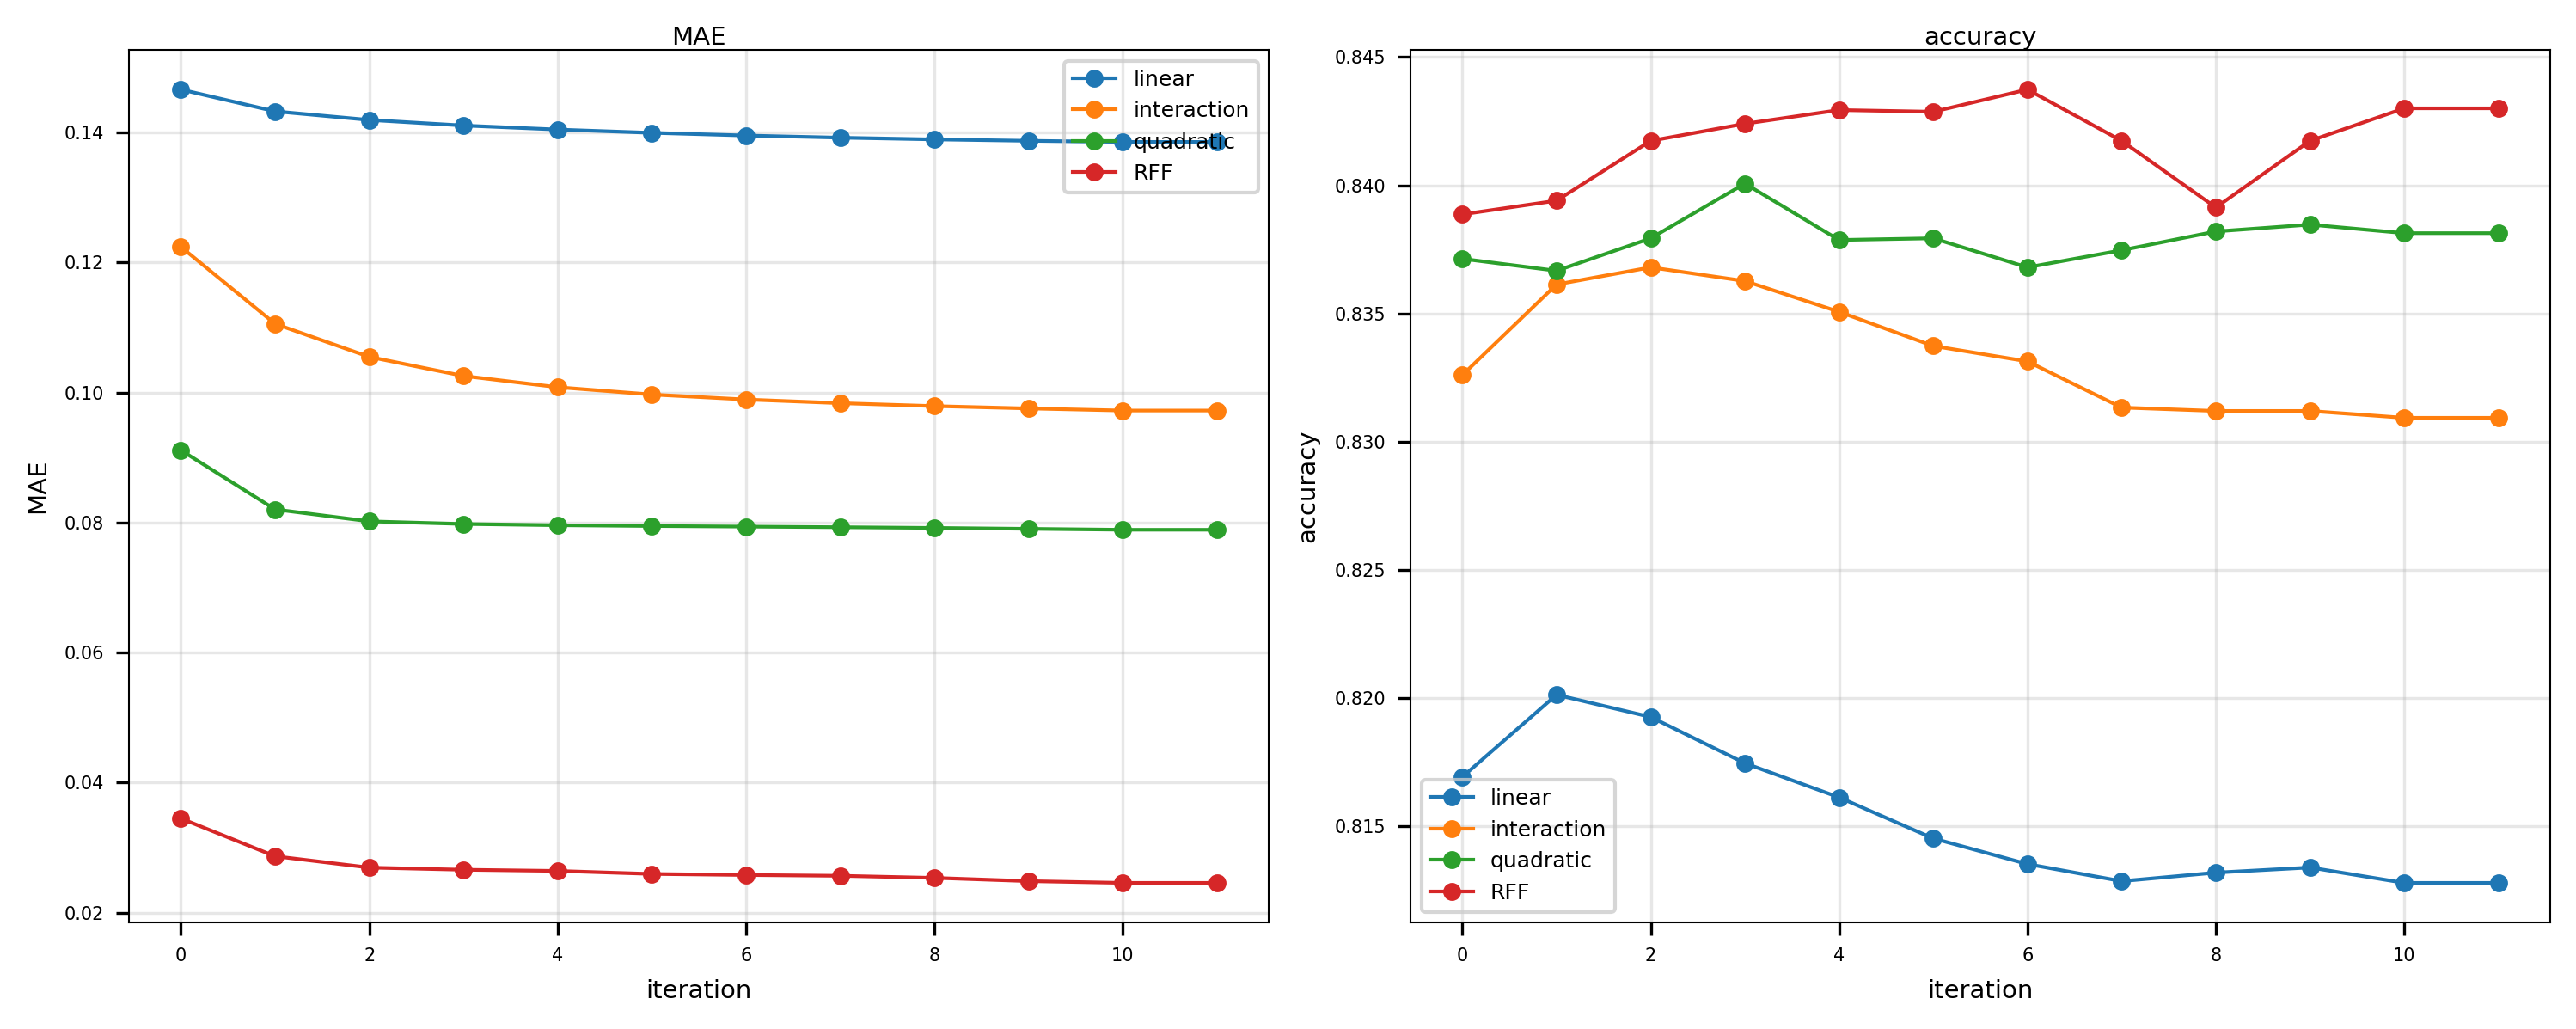

In [14]:
n_iters = 10
kernels = [
    ('linear', None),
    ('interaction', interaction_kernel),
    ('quadratic', quadratic_kernel),
    ('RFF', rff_kernel),
]

history = {}
for name, k in kernels:
    m = IXPLORE(reactions, kernel=k, random_state=0)
    m.iterate(n_iters)
    history[name] = pd.DataFrame(vars(m.fit_logger))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for name in history:
    axes[0].plot(history[name]['mae'], 'o-', label=name, markersize=4)
    axes[1].plot(history[name]['accuracy'], 'o-', label=name, markersize=4)
axes[0].set(xlabel='iteration', ylabel='MAE', title='MAE')
axes[1].set(xlabel='iteration', ylabel='accuracy', title='accuracy')
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()